# 1. Clean and Pre-processing

# 1.1 Load and Extract Price Data

In [15]:
import numpy as np
import pandas as pd
import yfinance as yf

from sklearn.preprocessing import StandardScaler


# Readable asset names mapped to Yahoo Finance tickers
TICKERS = {
    "Gold": "GC=F",
    "Silver": "SI=F",
    "WTI Oil": "CL=F",
    "USD Index": "DX-Y.NYB",
    "Bitcoin": "BTC-USD",
    "Ethereum": "ETH-USD",
}

# Download daily price data
raw = yf.download(
    list(TICKERS.values()),
    start="2016-01-01",
    end="2026-03-02",
    progress=False,
    auto_adjust=False
)

print("Raw data shape:", raw.shape)
print("Raw columns:")
print(raw.columns)

# Yahoo Finance data usually has MultiIndex columns:
# first level = price field, second level = ticker
fields = raw.columns.get_level_values(0)

# Prefer Adjusted Close if available
price_field = "Adj Close" if "Adj Close" in fields else "Close"

# Extract price data
prices = raw.xs(price_field, axis=1, level=0)

# Rename ticker columns to readable asset names
prices = prices.rename(columns={v: k for k, v in TICKERS.items()})

# Keep columns in the same order as TICKERS
prices = prices[list(TICKERS.keys())]

print("\nSelected price field:", price_field)
print("Price data shape:", prices.shape)

display(prices.head())
display(prices.tail())

Raw data shape: (3713, 36)
Raw columns:
MultiIndex([('Adj Close',  'BTC-USD'),
            ('Adj Close',     'CL=F'),
            ('Adj Close', 'DX-Y.NYB'),
            ('Adj Close',  'ETH-USD'),
            ('Adj Close',     'GC=F'),
            ('Adj Close',     'SI=F'),
            (    'Close',  'BTC-USD'),
            (    'Close',     'CL=F'),
            (    'Close', 'DX-Y.NYB'),
            (    'Close',  'ETH-USD'),
            (    'Close',     'GC=F'),
            (    'Close',     'SI=F'),
            (     'High',  'BTC-USD'),
            (     'High',     'CL=F'),
            (     'High', 'DX-Y.NYB'),
            (     'High',  'ETH-USD'),
            (     'High',     'GC=F'),
            (     'High',     'SI=F'),
            (      'Low',  'BTC-USD'),
            (      'Low',     'CL=F'),
            (      'Low', 'DX-Y.NYB'),
            (      'Low',  'ETH-USD'),
            (      'Low',     'GC=F'),
            (      'Low',     'SI=F'),
            (     'Open'

Ticker,Gold,Silver,WTI Oil,USD Index,Bitcoin,Ethereum
Date,,,,,,
2016-01-01,NaN,NaN,NaN,NaN,434.334015,NaN
2016-01-02,NaN,NaN,NaN,NaN,433.437988,NaN
2016-01-03,NaN,NaN,NaN,NaN,430.010986,NaN
2016-01-04,1075.099976,13.817,36.759998,98.870003,433.091003,NaN
2016-01-05,1078.400024,13.949,35.970001,99.400002,431.959991,NaN


Ticker,Gold,Silver,WTI Oil,USD Index,Bitcoin,Ethereum
Date,,,,,,
2026-02-25,5206.399902,90.939003,65.419998,97.699997,67960.125000,2054.627930
2026-02-26,5176.500000,86.998001,65.209999,97.790001,67453.773438,2026.792603
2026-02-27,5230.500000,92.681999,67.019997,97.610001,65881.796875,1930.761841
2026-02-28,NaN,NaN,NaN,NaN,66995.859375,1965.050537
2026-03-01,NaN,NaN,NaN,NaN,65738.101562,1939.066650


## 1.2 Data Quality Check and Cleaning

In [16]:
print("Date range before cleaning:")
print(prices.index.min().date(), "to", prices.index.max().date())

print("\nMissing values before cleaning:")
print(prices.isna().sum())

print("\nNumber of non-positive prices before cleaning:")
print((prices <= 0).sum())

print("\nPrice summary before cleaning:")
display(prices.describe())


# Replace non-positive prices with NaN.
# This is necessary because log returns require strictly positive prices.
prices_clean = prices.where(prices > 0)

# Drop dates where at least one asset has missing or invalid price.
# This creates a common trading-day dataset across all assets.
prices_clean = prices_clean.dropna(how="any")

print("\nDate range after cleaning:")
print(prices_clean.index.min().date(), "to", prices_clean.index.max().date())

print("\nCleaned price data shape:", prices_clean.shape)

print("\nMissing values after cleaning:")
print(prices_clean.isna().sum())

print("\nFirst 10 rows of cleaned prices:")
display(prices_clean.head(10))

print("\nLast 10 rows of cleaned prices:")
display(prices_clean.tail(10))

Date range before cleaning:
2016-01-01 to 2026-03-01

Missing values before cleaning:
Ticker
Gold         1161
Silver       1161
WTI Oil      1160
USD Index    1159
Bitcoin         0
Ethereum      678
dtype: int64

Number of non-positive prices before cleaning:
Ticker
Gold         0
Silver       0
WTI Oil      1
USD Index    0
Bitcoin      0
Ethereum     0
dtype: int64

Price summary before cleaning:


Ticker,Gold,Silver,WTI Oil,USD Index,Bitcoin,Ethereum
count,2552.000000,2552.000000,2553.000000,2554.000000,3713.000000,3035.000000
mean,1879.289653,23.515371,63.583737,98.506723,31075.061158,1702.084450
std,760.889947,11.254240,17.391401,4.989269,32450.421593,1291.141394
min,1073.900024,11.735000,-37.630001,88.589996,364.330994,84.308296
25%,1302.549988,16.833500,51.560001,94.782499,6476.290039,365.204605
50%,1766.699951,21.534000,63.380001,97.809998,18547.400391,1664.745605
75%,1975.325012,25.743750,74.080002,102.357500,48116.941406,2699.137939
max,5318.399902,115.080002,123.699997,114.110001,124752.531250,4831.348633



Date range after cleaning:
2017-11-09 to 2026-02-27

Cleaned price data shape: (2084, 6)

Missing values after cleaning:
Ticker
Gold         0
Silver       0
WTI Oil      0
USD Index    0
Bitcoin      0
Ethereum     0
dtype: int64

First 10 rows of cleaned prices:


Ticker,Gold,Silver,WTI Oil,USD Index,Bitcoin,Ethereum
Date,,,,,,
2017-11-09,1285.599976,16.943001,57.169998,94.440002,7143.580078,320.884003
2017-11-10,1272.400024,16.844000,56.740002,94.389999,6618.140137,299.252991
2017-11-13,1277.300049,17.023001,56.759998,94.489998,6559.490234,316.716003
2017-11-14,1281.500000,17.052000,55.700001,93.830002,6635.750000,337.631012
2017-11-15,1276.500000,16.950001,55.330002,93.809998,7315.540039,333.356995
2017-11-16,1277.400024,17.056000,55.139999,93.930000,7871.689941,330.924011
2017-11-17,1295.800049,17.358000,56.549999,93.660004,7708.990234,332.394012
2017-11-20,1274.599976,16.827000,56.090000,94.080002,8200.639648,366.730011
2017-11-21,1281.099976,16.948999,56.830002,93.949997,8071.259766,360.401001



Last 10 rows of cleaned prices:


Ticker,Gold,Silver,WTI Oil,USD Index,Bitcoin,Ethereum
Date,,,,,,
2026-02-13,5022.000000,77.850998,62.889999,96.879997,68857.843750,2048.527344
2026-02-17,4882.899902,73.446999,62.330002,97.160004,67494.218750,1992.194336
2026-02-18,4986.500000,77.509003,65.190002,97.699997,66425.320312,1953.974121
2026-02-19,4975.899902,77.565002,66.430000,97.930000,66957.523438,1948.201050
2026-02-20,5059.299805,82.282997,66.389999,97.800003,68005.421875,1969.022339
2026-02-23,5204.700195,86.523003,66.309998,97.699997,64616.738281,1855.502808
2026-02-24,5155.799805,87.457001,65.629997,97.879997,64080.042969,1852.969482
2026-02-25,5206.399902,90.939003,65.419998,97.699997,67960.125000,2054.627930
2026-02-26,5176.500000,86.998001,65.209999,97.790001,67453.773438,2026.792603


## 1.3 Compute Daily Log Returns

In [17]:
# Daily log return:
# r_t = log(P_t) - log(P_{t-1})

returns = np.log(prices_clean).diff().dropna()

print("Returns data shape:", returns.shape)

print("\nMissing values in returns:")
print(returns.isna().sum())

print("\nReturn summary statistics:")
display(returns.describe())

print("\nFirst 10 rows of returns:")
display(returns.head(10))

Returns data shape: (2083, 6)

Missing values in returns:
Ticker
Gold         0
Silver       0
WTI Oil      0
USD Index    0
Bitcoin      0
Ethereum     0
dtype: int64

Return summary statistics:


Ticker,Gold,Silver,WTI Oil,USD Index,Bitcoin,Ethereum
count,2083.000000,2083.000000,2083.000000,2083.000000,2083.000000,2083.000000
mean,0.000674,0.000816,0.000076,0.000016,0.001067,0.000862
std,0.010500,0.022459,0.031942,0.004195,0.042238,0.054963
min,-0.120657,-0.376103,-0.601676,-0.021394,-0.464730,-0.550732
25%,-0.004121,-0.008699,-0.012383,-0.002452,-0.016874,-0.024234
50%,0.000827,0.001002,0.001851,0.000000,0.000850,0.000213
75%,0.006066,0.010263,0.013772,0.002464,0.020144,0.026835
max,0.059054,0.131250,0.319634,0.016389,0.225119,0.343523



First 10 rows of returns:


Ticker,Gold,Silver,WTI Oil,USD Index,Bitcoin,Ethereum
Date,,,,,,
2017-11-10,-0.010321,-0.005860,-0.007550,-0.000530,-0.076400,-0.069790
2017-11-13,0.003844,0.010571,0.000352,0.001059,-0.008901,0.056716
2017-11-14,0.003283,0.001702,-0.018852,-0.007009,0.011559,0.063948
2017-11-15,-0.003909,-0.006000,-0.006665,-0.000213,0.097529,-0.012740
2017-11-16,0.000705,0.006234,-0.003440,0.001278,0.073272,-0.007325
2017-11-17,0.014302,0.017551,0.025250,-0.002879,-0.020886,0.004432
2017-11-20,-0.016496,-0.031069,-0.008168,0.004474,0.061825,0.098305
2017-11-21,0.005087,0.007224,0.013107,-0.001383,-0.015903,-0.017409
2017-11-22,0.008163,0.008928,0.020723,-0.007800,0.022334,0.054668


## 1.4 Create Basic Machine Learning Features and Target

In [18]:
def create_ml_features(returns, target_asset="Bitcoin"):
    """
    Create a supervised learning table for machine learning models.

    Target:
        Next-day return of the selected target asset.

    Basic features:
        1. Lagged returns for all assets
        2. Rolling mean returns for all assets
        3. Rolling volatility for all assets
    """

    df = returns.copy()
    feature_data = pd.DataFrame(index=df.index)

    # Lag features: previous 1, 2, 3, and 5 days' returns
    lags = [1, 2, 3, 5]

    for asset in df.columns:
        for lag in lags:
            feature_data[f"{asset}_lag{lag}"] = df[asset].shift(lag)

    # Rolling window features
    rolling_windows = [5, 10, 20]

    for asset in df.columns:
        for window in rolling_windows:
            feature_data[f"{asset}_rollmean{window}"] = df[asset].rolling(window).mean()
            feature_data[f"{asset}_rollvol{window}"] = df[asset].rolling(window).std()

    # Target variable: next-day return of the selected asset
    target_col = f"{target_asset}_target_next_return"
    feature_data[target_col] = df[target_asset].shift(-1)

    # Remove rows with NaN caused by lags, rolling windows, and target shifting
    feature_data = feature_data.dropna()

    return feature_data, target_col


ml_data, target_col = create_ml_features(returns, target_asset="Bitcoin")

# Separate features and target
X = ml_data.drop(columns=[target_col])
y = ml_data[target_col]

print("Machine learning dataset shape:", ml_data.shape)
print("Feature matrix shape:", X.shape)
print("Target vector shape:", y.shape)

print("\nTarget column:", target_col)

print("\nFirst 10 feature columns:")
print(X.columns.tolist()[:10])

display(ml_data.head())

Machine learning dataset shape: (2063, 61)
Feature matrix shape: (2063, 60)
Target vector shape: (2063,)

Target column: Bitcoin_target_next_return

First 10 feature columns:
['Gold_lag1', 'Gold_lag2', 'Gold_lag3', 'Gold_lag5', 'Silver_lag1', 'Silver_lag2', 'Silver_lag3', 'Silver_lag5', 'WTI Oil_lag1', 'WTI Oil_lag2']


,Gold_lag1,Gold_lag2,Gold_lag3,Gold_lag5,Silver_lag1,Silver_lag2,Silver_lag3,Silver_lag5,WTI Oil_lag1,WTI Oil_lag2,...,Bitcoin_rollvol10,Bitcoin_rollmean20,Bitcoin_rollvol20,Ethereum_rollmean5,Ethereum_rollvol5,Ethereum_rollmean10,Ethereum_rollvol10,Ethereum_rollmean20,Ethereum_rollvol20,Bitcoin_target_next_return
Date,,,,,,,,,,,,,,,,,,,,,
2017-12-08,-0.010348,0.000951,-0.010016,0.004389,-0.009689,-0.006595,-0.019283,-0.005202,0.012961,-0.029233,...,0.095627,0.042067,0.079939,-0.004557,0.046845,-0.004057,0.050645,0.017574,0.069353,0.021931
2017-12-11,-0.003687,-0.010348,0.000951,-0.003525,0.001335,-0.009689,-0.006595,-0.000798,0.011749,0.012961,...,0.089123,0.046984,0.075150,0.018253,0.074173,0.006991,0.064535,0.027157,0.069886,0.027866
2017-12-12,-0.001205,-0.003687,-0.010348,-0.010016,-0.002482,0.001335,-0.009689,-0.019283,0.010923,0.011749,...,0.088991,0.048822,0.074154,0.068168,0.117603,0.032028,0.095784,0.036058,0.083801,-0.059574
2017-12-13,-0.004190,-0.001205,-0.003687,0.000951,-0.007353,-0.002482,0.001335,-0.006595,-0.014766,0.010923,...,0.093701,0.045265,0.077658,0.098906,0.085643,0.049702,0.084133,0.036654,0.084051,0.009451
2017-12-14,0.005556,-0.004190,-0.001205,-0.010348,0.012880,-0.007353,-0.002482,-0.009689,-0.009495,-0.014766,...,0.094509,0.040862,0.077034,0.094220,0.091897,0.044227,0.086241,0.036794,0.083967,0.066723


## 1.5 Time-Based Train-Test Split and Feature Scaling

In [19]:
# For time series data, split by chronological order.
# Do not randomly shuffle observations.

split_idx = int(len(ml_data) * 0.7)

X_train = X.iloc[:split_idx]
X_test = X.iloc[split_idx:]

y_train = y.iloc[:split_idx]
y_test = y.iloc[split_idx:]

print("Training period:")
print(X_train.index.min().date(), "to", X_train.index.max().date())

print("\nTesting period:")
print(X_test.index.min().date(), "to", X_test.index.max().date())

print("\nBefore scaling:")
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)


# Standardize features.
# Important: fit the scaler only on the training set to avoid data leakage.
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convert scaled arrays back to DataFrames
X_train_scaled = pd.DataFrame(
    X_train_scaled,
    index=X_train.index,
    columns=X_train.columns
)

X_test_scaled = pd.DataFrame(
    X_test_scaled,
    index=X_test.index,
    columns=X_test.columns
)

print("\nScaled training feature summary:")
display(X_train_scaled.describe().T.head())

print("\nScaled testing feature summary:")
display(X_test_scaled.describe().T.head())

Training period:
2017-12-08 to 2023-09-08

Testing period:
2023-09-11 to 2026-02-26

Before scaling:
X_train shape: (1444, 60)
X_test shape: (619, 60)
y_train shape: (1444,)
y_test shape: (619,)

Scaled training feature summary:


,count,mean,std,min,25%,50%,75%,max
Gold_lag1,1444.0,-1.968262e-17,1.000346,-5.446611,-0.464405,0.018473,0.493853,6.096401
Gold_lag2,1444.0,-4.920656e-18,1.000346,-5.446702,-0.464497,0.018669,0.493760,6.096307
Gold_lag3,1444.0,1.230164e-17,1.000346,-5.444454,-0.463916,0.019088,0.494021,6.094694
Gold_lag5,1444.0,9.841312e-18,1.000346,-5.445452,-0.459507,0.018571,0.493545,6.094710
Silver_lag1,1444.0,-4.920656e-18,1.000346,-6.497395,-0.477311,0.012581,0.459089,4.635498



Scaled testing feature summary:


,count,mean,std,min,25%,50%,75%,max
Gold_lag1,619.0,0.140455,1.343369,-12.826404,-0.470059,0.201730,0.820440,6.232071
Gold_lag2,619.0,0.138636,1.342942,-12.826493,-0.470152,0.196583,0.815722,6.231976
Gold_lag3,619.0,0.139910,1.341896,-12.821778,-0.469569,0.196943,0.815875,6.230318
Gold_lag5,619.0,0.130639,1.336113,-12.823424,-0.472823,0.176645,0.812850,6.230347
Silver_lag1,619.0,0.103070,1.508107,-19.703119,-0.453565,0.099308,0.711861,6.857811


## 1.6 Final Preprocessed Data Check and Save Files

In [8]:
print("Final data check:")

print("\nNaN values:")
print("X_train_scaled:", X_train_scaled.isna().sum().sum())
print("X_test_scaled:", X_test_scaled.isna().sum().sum())
print("y_train:", y_train.isna().sum())
print("y_test:", y_test.isna().sum())

print("\nInfinite values:")
print("X_train_scaled:", np.isinf(X_train_scaled.to_numpy()).sum())
print("X_test_scaled:", np.isinf(X_test_scaled.to_numpy()).sum())
print("y_train:", np.isinf(y_train.to_numpy()).sum())
print("y_test:", np.isinf(y_test.to_numpy()).sum())

print("\nFinal shapes:")
print("prices_clean:", prices_clean.shape)
print("returns:", returns.shape)
print("ml_data:", ml_data.shape)
print("X_train_scaled:", X_train_scaled.shape)
print("X_test_scaled:", X_test_scaled.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)


# Save cleaned and preprocessed datasets
prices_clean.to_csv("cleaned_asset_prices.csv")
returns.to_csv("asset_log_returns.csv")
ml_data.to_csv("ml_features_bitcoin_target.csv")

X_train_scaled.to_csv("X_train_scaled.csv")
X_test_scaled.to_csv("X_test_scaled.csv")
y_train.to_csv("y_train.csv")
y_test.to_csv("y_test.csv")

print("\nFiles saved successfully.")

Machine learning dataset shape: (2063, 61)


,Gold_lag1,Gold_lag2,Gold_lag3,Gold_lag5,Silver_lag1,Silver_lag2,Silver_lag3,Silver_lag5,WTI Oil_lag1,WTI Oil_lag2,...,USD Index_rollvol5,USD Index_rollvol10,USD Index_rollvol20,Bitcoin_rollvol5,Bitcoin_rollvol10,Bitcoin_rollvol20,Ethereum_rollvol5,Ethereum_rollvol10,Ethereum_rollvol20,Bitcoin_target_next_return
Date,,,,,,,,,,,,,,,,,,,,,
2017-12-08,-0.010348,0.000951,-0.010016,0.004389,-0.009689,-0.006595,-0.019283,-0.005202,0.012961,-0.029233,...,0.000747,0.002002,0.003380,0.122323,0.095627,0.079939,0.046845,0.050645,0.069353,0.021931
2017-12-11,-0.003687,-0.010348,0.000951,-0.003525,0.001335,-0.009689,-0.006595,-0.000798,0.011749,0.012961,...,0.001115,0.002056,0.003380,0.125221,0.089123,0.075150,0.074173,0.064535,0.069886,0.027866
2017-12-12,-0.001205,-0.003687,-0.010348,-0.010016,-0.002482,0.001335,-0.009689,-0.019283,0.010923,0.011749,...,0.001182,0.001880,0.003423,0.124632,0.088991,0.074154,0.117603,0.095784,0.083801,-0.059574
2017-12-13,-0.004190,-0.001205,-0.003687,0.000951,-0.007353,-0.002482,0.001335,-0.006595,-0.014766,0.010923,...,0.003926,0.003173,0.003437,0.120035,0.093701,0.077658,0.085643,0.084133,0.084051,0.009451
2017-12-14,0.005556,-0.004190,-0.001205,-0.010348,0.012880,-0.007353,-0.002482,-0.009689,-0.009495,-0.014766,...,0.003758,0.003009,0.003442,0.049135,0.094509,0.077034,0.091897,0.086241,0.083967,0.066723


## 1.7 Separate Features and Target

In [9]:
target_col = "Bitcoin_target_next_return"

X = ml_data.drop(columns=[target_col])
y = ml_data[target_col]

print("Feature matrix shape:", X.shape)
print("Target vector shape:", y.shape)

print("\nFeature columns:")
print(X.columns.tolist()[:20], "...")

Feature matrix shape: (2063, 60)
Target vector shape: (2063,)

Feature columns:
['Gold_lag1', 'Gold_lag2', 'Gold_lag3', 'Gold_lag5', 'Silver_lag1', 'Silver_lag2', 'Silver_lag3', 'Silver_lag5', 'WTI Oil_lag1', 'WTI Oil_lag2', 'WTI Oil_lag3', 'WTI Oil_lag5', 'USD Index_lag1', 'USD Index_lag2', 'USD Index_lag3', 'USD Index_lag5', 'Bitcoin_lag1', 'Bitcoin_lag2', 'Bitcoin_lag3', 'Bitcoin_lag5'] ...


## 1.8 Time-Based Train-Test Split

In [12]:
# For time series data, we should split by time order.
# Do NOT randomly shuffle the observations.

split_idx = int(len(ml_data) * 0.7)

X_train = X.iloc[:split_idx]
X_test = X.iloc[split_idx:]

y_train = y.iloc[:split_idx]
y_test = y.iloc[split_idx:]

print("Training period:")
print(X_train.index.min().date(), "to", X_train.index.max().date())

print("\nTesting period:")
print(X_test.index.min().date(), "to", X_test.index.max().date())

print("\nX_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

Training period:
2017-12-08 to 2023-09-08

Testing period:
2023-09-11 to 2026-02-26

X_train shape: (1444, 60)
X_test shape: (619, 60)
y_train shape: (1444,)
y_test shape: (619,)


## 1.9. Standardize Features

In [13]:
# Standardization is important for models such as:
# Ridge Regression, Lasso, Elastic Net, KNN, SVM, Neural Networks.

# Important:
# Fit the scaler only on the training set to avoid data leakage.

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convert scaled arrays back to DataFrames for easier interpretation
X_train_scaled = pd.DataFrame(
    X_train_scaled,
    index=X_train.index,
    columns=X_train.columns
)

X_test_scaled = pd.DataFrame(
    X_test_scaled,
    index=X_test.index,
    columns=X_test.columns
)

print("Scaled training feature summary:")
display(X_train_scaled.describe().T.head())

print("\nScaled testing feature summary:")
display(X_test_scaled.describe().T.head())

Scaled training feature summary:


,count,mean,std,min,25%,50%,75%,max
Gold_lag1,1444.0,-1.968262e-17,1.000346,-5.446611,-0.464405,0.018473,0.493853,6.096401
Gold_lag2,1444.0,-4.920656e-18,1.000346,-5.446702,-0.464497,0.018669,0.493760,6.096307
Gold_lag3,1444.0,1.230164e-17,1.000346,-5.444454,-0.463916,0.019088,0.494021,6.094694
Gold_lag5,1444.0,9.841312e-18,1.000346,-5.445452,-0.459507,0.018571,0.493545,6.094710
Silver_lag1,1444.0,-4.920656e-18,1.000346,-6.497395,-0.477311,0.012581,0.459089,4.635498



Scaled testing feature summary:


,count,mean,std,min,25%,50%,75%,max
Gold_lag1,619.0,0.140455,1.343369,-12.826404,-0.470059,0.201730,0.820440,6.232071
Gold_lag2,619.0,0.138636,1.342942,-12.826493,-0.470152,0.196583,0.815722,6.231976
Gold_lag3,619.0,0.139910,1.341896,-12.821778,-0.469569,0.196943,0.815875,6.230318
Gold_lag5,619.0,0.130639,1.336113,-12.823424,-0.472823,0.176645,0.812850,6.230347
Silver_lag1,619.0,0.103070,1.508107,-19.703119,-0.453565,0.099308,0.711861,6.857811


## 1.10 Final Preprocessed Data Check

In [14]:
print("Final data check:")

print("\nNaN values:")
print("X_train:", X_train_scaled.isna().sum().sum())
print("X_test:", X_test_scaled.isna().sum().sum())
print("y_train:", y_train.isna().sum())
print("y_test:", y_test.isna().sum())

print("\nInfinite values:")
print("X_train:", np.isinf(X_train_scaled.to_numpy()).sum())
print("X_test:", np.isinf(X_test_scaled.to_numpy()).sum())
print("y_train:", np.isinf(y_train.to_numpy()).sum())
print("y_test:", np.isinf(y_test.to_numpy()).sum())

print("\nFinal shapes:")
print("X_train_scaled:", X_train_scaled.shape)
print("X_test_scaled:", X_test_scaled.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

Final data check:

NaN values:
X_train: 0
X_test: 0
y_train: 0
y_test: 0

Infinite values:
X_train: 0
X_test: 0
y_train: 0
y_test: 0

Final shapes:
X_train_scaled: (1444, 60)
X_test_scaled: (619, 60)
y_train: (1444,)
y_test: (619,)


## 2. EDA

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (12, 6)

TRADING_DAYS = 252
annual_vol = returns.std() * np.sqrt(TRADING_DAYS)
annual_mean = returns.mean() * TRADING_DAYS

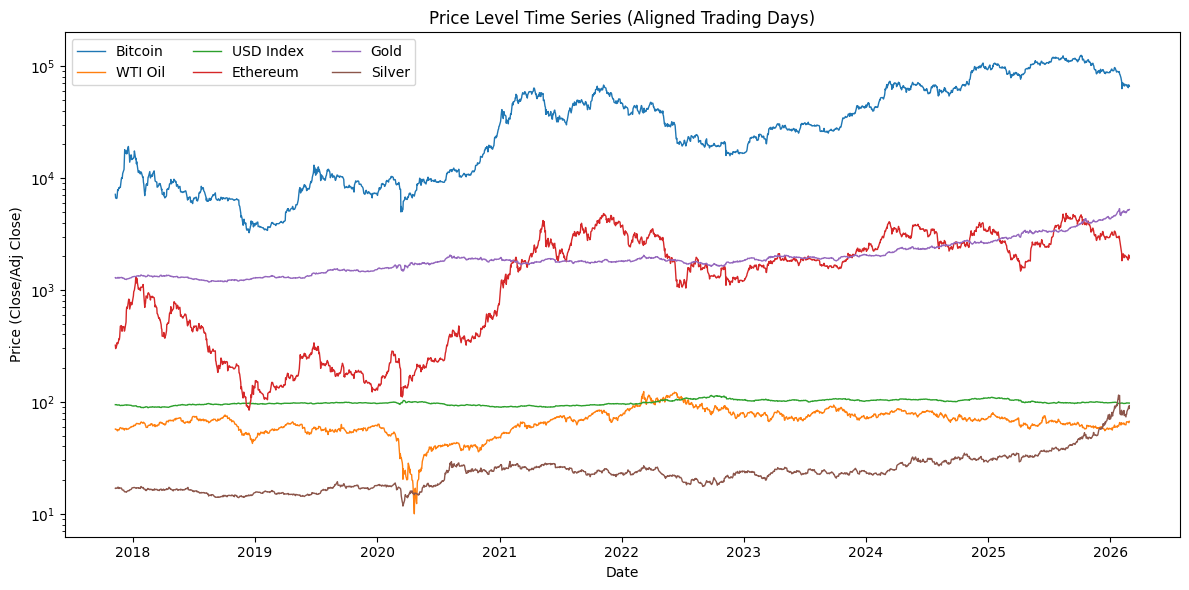

In [7]:
# Plot 1) Price level time series (all 6 assets)
plt.figure()
for col in prices_clean.columns:
    plt.plot(prices_clean.index, prices_clean[col], label=col, linewidth=1)
plt.title("Price Level Time Series (Aligned Trading Days)")
plt.xlabel("Date")
plt.ylabel("Price (Close/Adj Close)")
plt.yscale("log")
plt.legend(ncol=3)
plt.tight_layout()
plt.show()

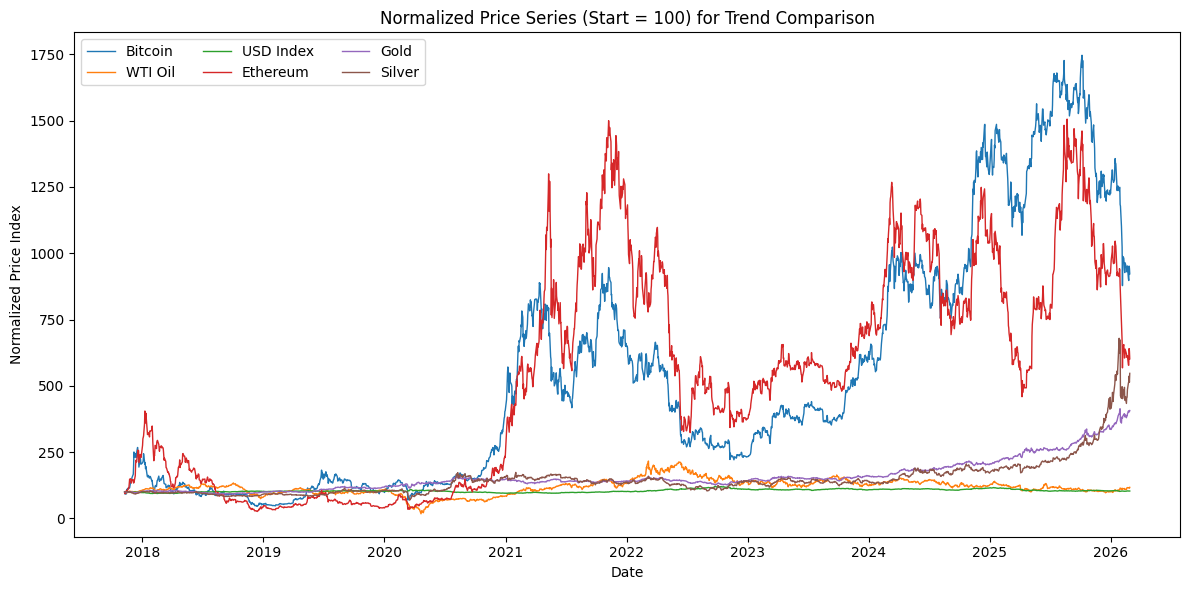

In [8]:
# Plot 2) Normalized price series (start=100) to compare trend
normalized = (prices_clean / prices_clean.iloc[0]) * 100

plt.figure()
for col in normalized.columns:
    plt.plot(normalized.index, normalized[col], label=col, linewidth=1)
plt.title("Normalized Price Series (Start = 100) for Trend Comparison")
plt.xlabel("Date")
plt.ylabel("Normalized Price Index")
plt.legend(ncol=3)
plt.tight_layout()
plt.show()

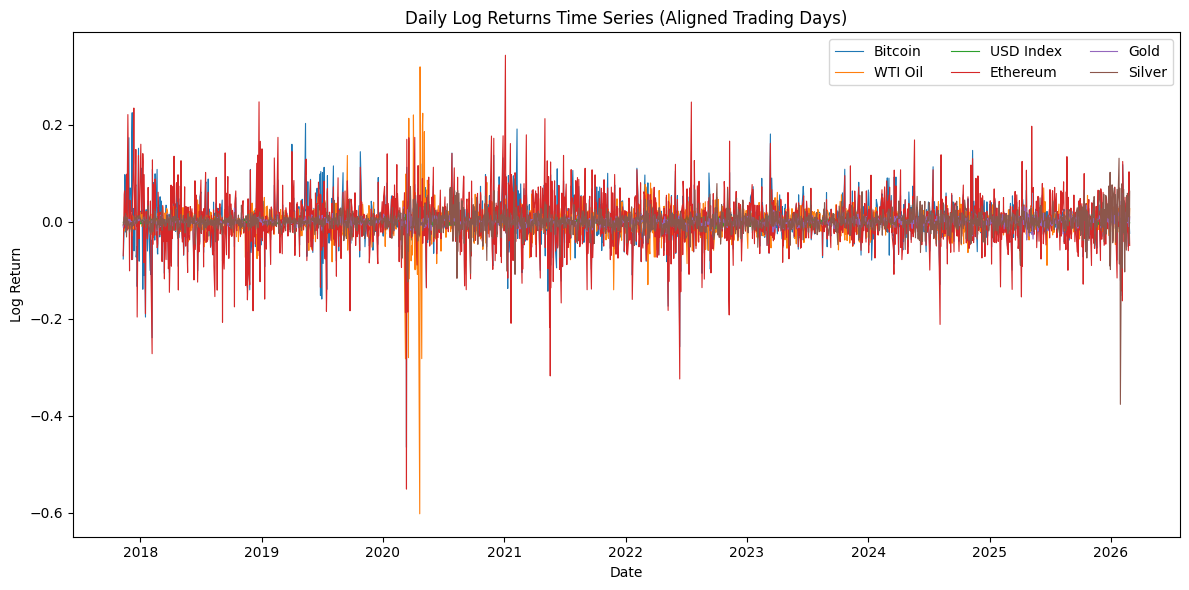

array([<Axes: xlabel='Date'>, <Axes: xlabel='Date'>,
       <Axes: xlabel='Date'>, <Axes: xlabel='Date'>,
       <Axes: xlabel='Date'>, <Axes: xlabel='Date'>], dtype=object)

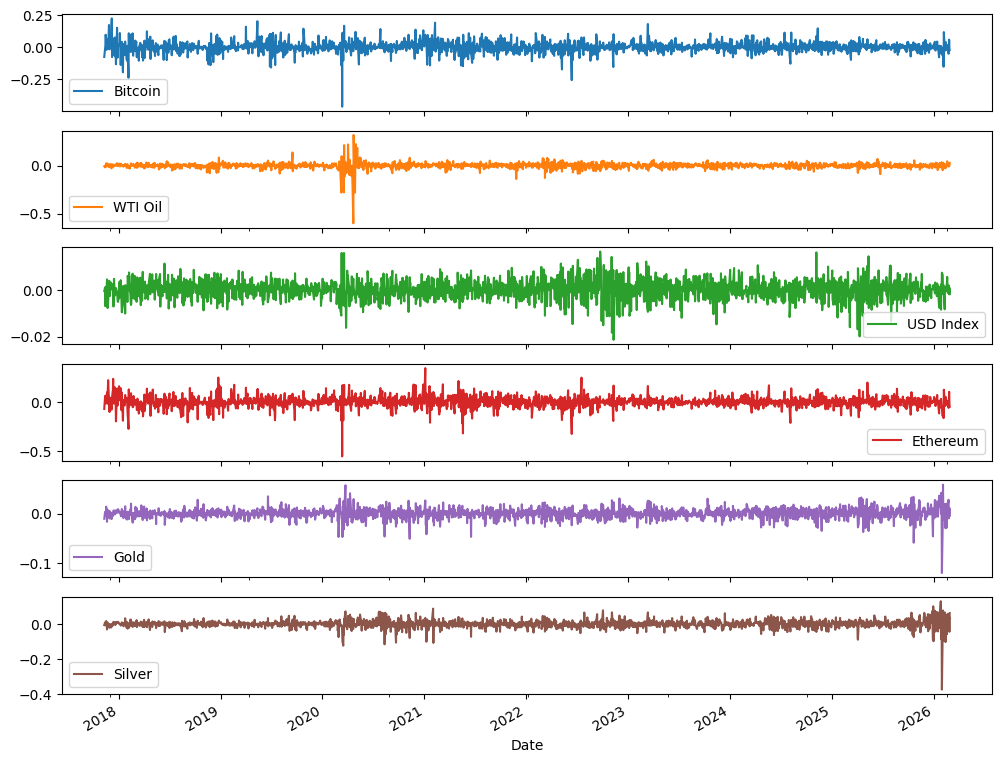

In [9]:
# Plot 3) Log return time series (all 6 assets)
plt.figure()
for col in returns.columns:
    plt.plot(returns.index, returns[col], label=col, linewidth=0.8)
plt.title("Daily Log Returns Time Series (Aligned Trading Days)")
plt.xlabel("Date")
plt.ylabel("Log Return")
plt.legend(ncol=3)
plt.tight_layout()
plt.show()

returns.plot(subplots=True, figsize=(12,10))

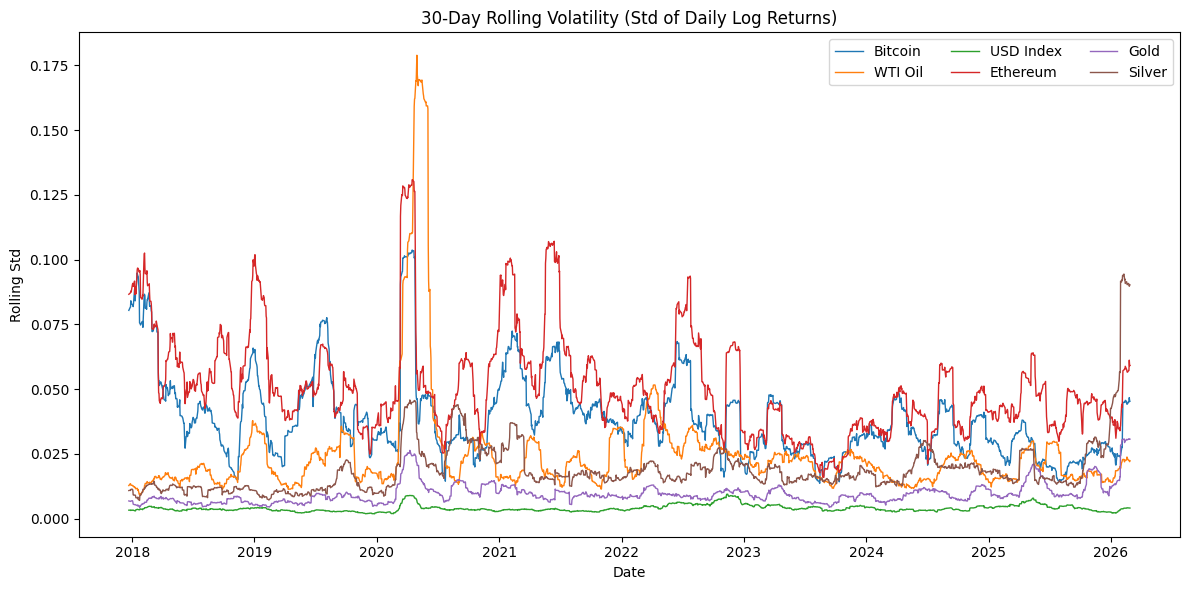

In [10]:
# Plot 4) Rolling volatility comparison (30-day rolling std)
window = 30
rolling_vol = returns.rolling(window).std()

plt.figure()
for col in rolling_vol.columns:
    plt.plot(rolling_vol.index, rolling_vol[col], label=col, linewidth=1)
plt.title(f"{window}-Day Rolling Volatility (Std of Daily Log Returns)")
plt.xlabel("Date")
plt.ylabel("Rolling Std")
plt.legend(ncol=3)
plt.tight_layout()
plt.show()

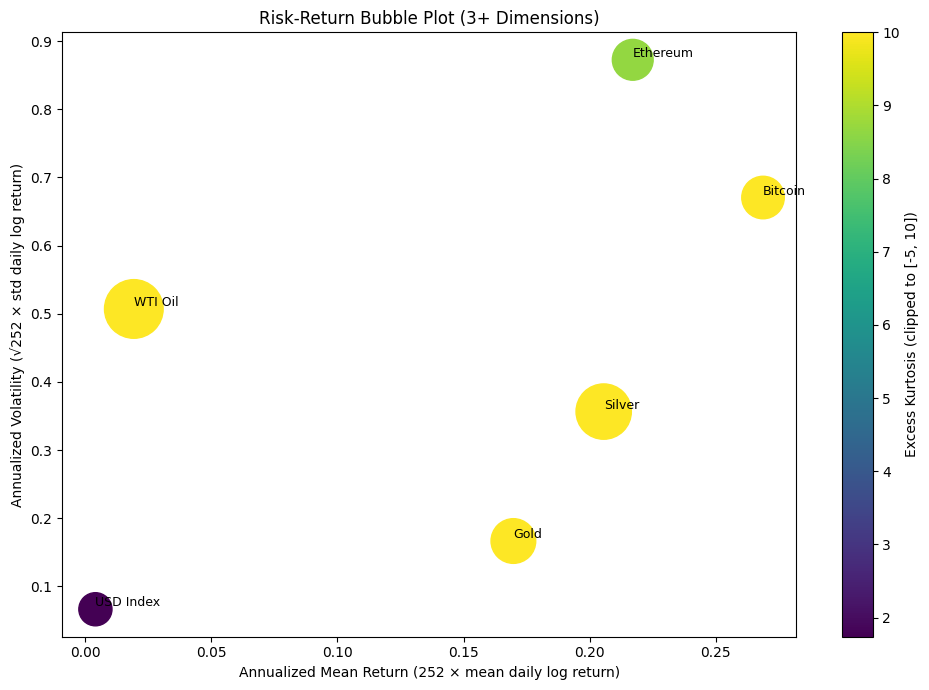

In [11]:
# Plot 5) Risk-Return Bubble Plot (3+ dimensions)
#   x-axis  : annualized mean return (252 * mean daily log return)
#   y-axis  : annualized volatility (sqrt(252) * std daily log return)
#   size    : absolute skewness (3rd dimension)
#   color   : excess kurtosis (4th dimension), clipped for readability

# Skewness & excess kurtosis (pandas Series indexed by asset)
skew = returns.skew()                 # skewness
ex_kurt = returns.kurtosis()          # pandas default is excess (Fisher) kurtosis

# Align indices just in case
x = annual_mean.reindex(returns.columns)
y = annual_vol.reindex(returns.columns)
skew = skew.reindex(returns.columns)
ex_kurt = ex_kurt.reindex(returns.columns)

# Bubble size scaling (stable + readable)
# Use sqrt to reduce extreme size differences; add floor so small bubbles still visible
sizes = (np.sqrt(np.abs(skew)) + 0.2) * 900

# Clip kurtosis for color stability (WTI can be extreme due to shock events)
kurt_clip_low, kurt_clip_high = -5, 10
color_vals = ex_kurt.clip(lower=kurt_clip_low, upper=kurt_clip_high)

plt.figure(figsize=(10, 7))
sc = plt.scatter(
    x, y,
    s=sizes,
    c=color_vals
)

# Label each point
for asset in x.index:
    plt.text(x[asset], y[asset], asset, fontsize=9, ha="left", va="bottom")

plt.title("Risk-Return Bubble Plot (3+ Dimensions)")
plt.xlabel("Annualized Mean Return (252 × mean daily log return)")
plt.ylabel("Annualized Volatility (√252 × std daily log return)")

cbar = plt.colorbar(sc)
cbar.set_label(f"Excess Kurtosis (clipped to [{kurt_clip_low}, {kurt_clip_high}])")

plt.tight_layout()
plt.show()

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error, mean_absolute_error

In [13]:
asset = "Bitcoin"
series = returns[asset].dropna()

print("Selected asset:", asset)
print("Length of series:", len(series))
series.head()

Selected asset: Bitcoin
Length of series: 2083


Date
2017-11-10   -0.076400
2017-11-13   -0.008901
2017-11-14    0.011559
2017-11-15    0.097529
2017-11-16    0.073272
Name: Bitcoin, dtype: float64

In [14]:
split = int(len(series) * 0.7)

train = series.iloc[:split]
test = series.iloc[split:]

print("Train size:", len(train))
print("Test size:", len(test))
print("Train period:", train.index.min().date(), "to", train.index.max().date())
print("Test period:", test.index.min().date(), "to", test.index.max().date())

Train size: 1458
Test size: 625
Train period: 2017-11-10 to 2023-08-31
Test period: 2023-09-01 to 2026-02-27


CV Results Summary
Number of folds: 21
Average MSE: 0.0009040462090396907
Average MAE: 0.022832235751604705


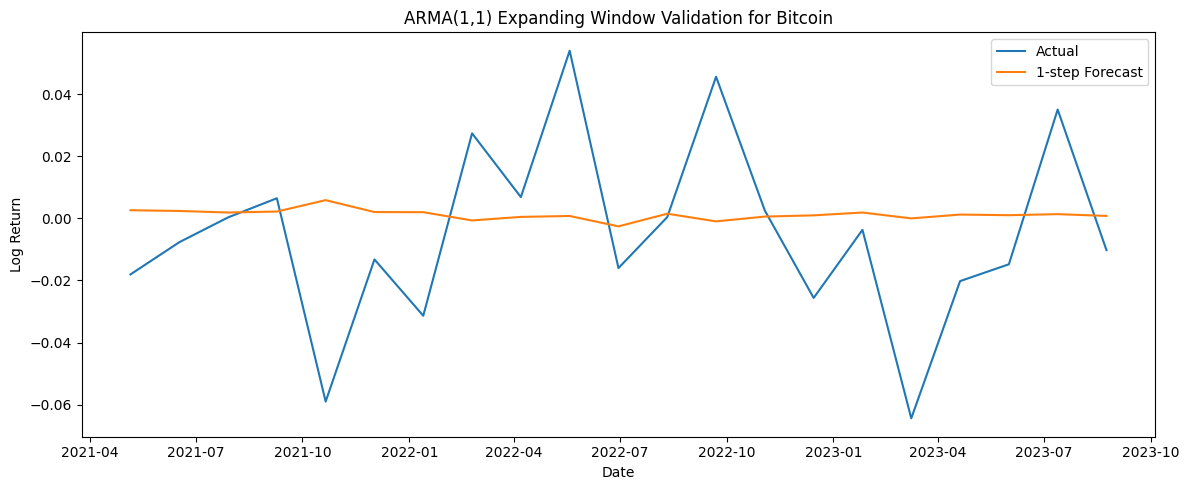

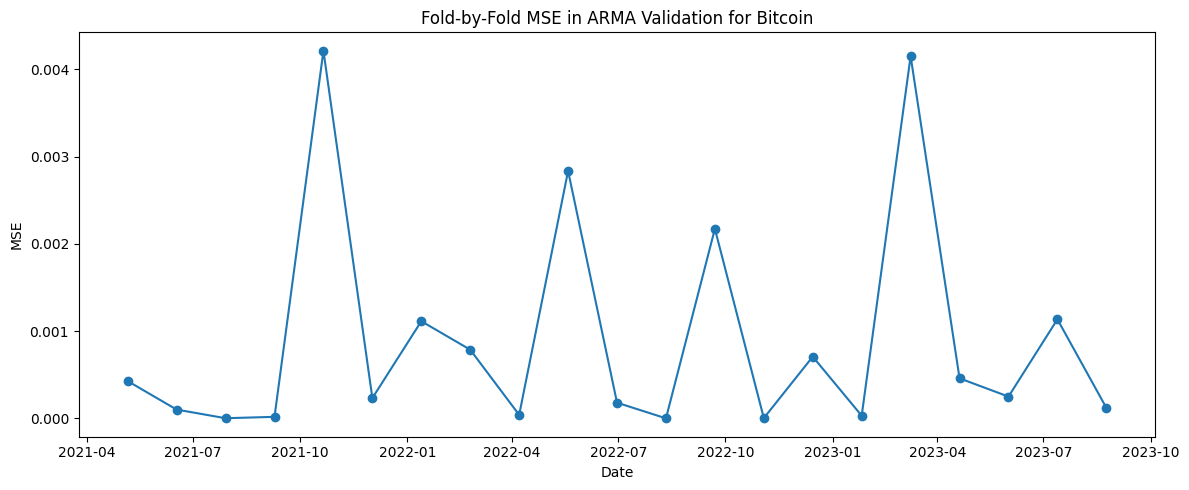

In [47]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Select asset
asset = "Bitcoin"
series = returns[asset].dropna().astype(float)

# Ensure datetime index and set business day frequency
series.index = pd.to_datetime(series.index)
series = series.asfreq('B')

# Train-test split (70% train, 30% test)
split = int(len(series) * 0.7)
train = series.iloc[:split]
test = series.iloc[split:]

# Expanding window cross-validation
initial_train_size = int(len(train) * 0.6)
step_size = 30
forecast_horizon = 1

cv_results = []

for end_train in range(initial_train_size, len(train) - forecast_horizon, step_size):
    train_cv = train.iloc[:end_train]
    test_cv = train.iloc[end_train:end_train + forecast_horizon]

    try:
        model_cv = ARIMA(train_cv, order=(1, 0, 1))
        res_cv = model_cv.fit()

        forecast_cv = res_cv.forecast(steps=forecast_horizon)

        mse_cv = mean_squared_error(test_cv, forecast_cv)
        mae_cv = mean_absolute_error(test_cv, forecast_cv)

        cv_results.append({
            "date": test_cv.index[0],
            "actual": test_cv.values[0],
            "forecast": forecast_cv.values[0],
            "mse": mse_cv,
            "mae": mae_cv
        })

    except Exception as e:
        print(f"Skipped fold due to error: {e}")

cv_df = pd.DataFrame(cv_results)

# CV summary
print("CV Results Summary")
print("Number of folds:", len(cv_df))
print("Average MSE:", cv_df["mse"].mean())
print("Average MAE:", cv_df["mae"].mean())

# Plot: actual vs forecast across folds
plt.figure(figsize=(12, 5))
plt.plot(cv_df["date"], cv_df["actual"], label="Actual")
plt.plot(cv_df["date"], cv_df["forecast"], label="1-step Forecast")

plt.title(f"ARMA(1,1) Expanding Window Validation for {asset}")
plt.xlabel("Date")
plt.ylabel("Log Return")
plt.legend()
plt.tight_layout()
plt.show()

# Plot: fold-by-fold errors
plt.figure(figsize=(12, 5))
plt.plot(cv_df["date"], cv_df["mse"], marker="o")

plt.title(f"Fold-by-Fold MSE in ARMA Validation for {asset}")
plt.xlabel("Date")
plt.ylabel("MSE")
plt.tight_layout()
plt.show()

Before dropna: (650, 2)
After dropna: (624, 2)
Final Test MSE: 0.0009637557417327802
Final Test MAE: 0.02252780443081249


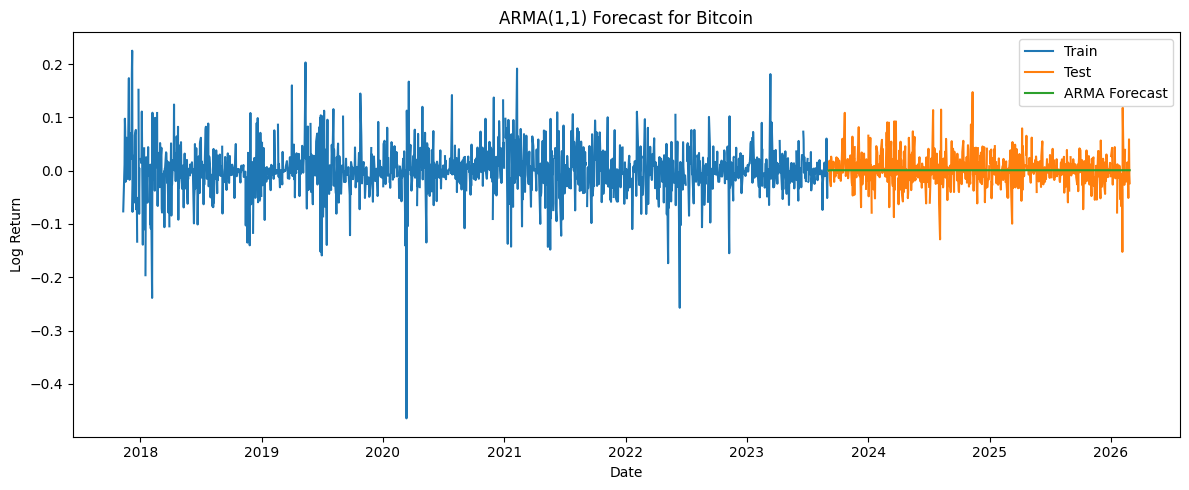

In [46]:
# Fit final model on full training data
arma_model = ARIMA(train, order=(1, 0, 1))
arma_res = arma_model.fit()

# Forecast on test set
arma_forecast = arma_res.forecast(steps=len(test))
arma_forecast = pd.Series(arma_forecast.values, index=test.index)

# Combine actual and forecast
eval_df = pd.concat([test, arma_forecast], axis=1)
eval_df.columns = ["Actual", "Forecast"]

print("Before dropna:", eval_df.shape)
eval_df = eval_df.dropna()
print("After dropna:", eval_df.shape)

# Compute evaluation metrics
arma_mse = mean_squared_error(eval_df["Actual"], eval_df["Forecast"])
arma_mae = mean_absolute_error(eval_df["Actual"], eval_df["Forecast"])

print("Final Test MSE:", arma_mse)
print("Final Test MAE:", arma_mae)

# Plot final results
plt.figure(figsize=(12, 5))
plt.plot(train.index, train, label="Train")
plt.plot(test.index, test, label="Test")
plt.plot(test.index, arma_forecast, label="ARMA Forecast")

plt.title(f"ARMA(1,1) Forecast for {asset}")
plt.xlabel("Date")
plt.ylabel("Log Return")
plt.legend()
plt.tight_layout()
plt.show()

In [38]:
import numpy as np
import pandas as pd
from statsmodels.stats.diagnostic import het_arch

# ARMA residuals
arma_resid = pd.Series(arma_res.resid, index=train.index)

# Clean residuals before ARCH-LM test
arma_resid = arma_resid.replace([np.inf, -np.inf], np.nan).dropna()

print("Number of residual observations used in ARCH-LM test:", len(arma_resid))
print(arma_resid.head())

# ARCH-LM test
arch_test = het_arch(arma_resid, nlags=10)

lm_stat = arch_test[0]
lm_pvalue = arch_test[1]
f_stat = arch_test[2]
f_pvalue = arch_test[3]

print("ARCH-LM Test Results")
print(f"LM Statistic: {lm_stat:.4f}")
print(f"LM p-value: {lm_pvalue:.6f}")
print(f"F Statistic: {f_stat:.4f}")
print(f"F p-value: {f_pvalue:.6f}")

Number of residual observations used in ARCH-LM test: 1459
Date
2017-11-10   -0.077274
2017-11-13   -0.008480
2017-11-14    0.011652
2017-11-15    0.097080
2017-11-16    0.071068
dtype: float64
ARCH-LM Test Results
LM Statistic: 31.6197
LM p-value: 0.000463
F Statistic: 3.2080
F p-value: 0.000430


In [40]:
from arch import arch_model

# Get ARMA residuals
arma_resid = pd.Series(arma_res.resid, index=train.index) * 100

# Clean residuals (VERY IMPORTANT)
arma_resid = arma_resid.replace([np.inf, -np.inf], np.nan).dropna()

print(arma_resid.head())

# Fit GARCH(1,1)
garch_model = arch_model(
    arma_resid,
    mean="Zero",
    vol="GARCH",
    p=1,
    q=1,
    dist="normal"
)

garch_res = garch_model.fit(disp="off")

print(garch_res.summary())

Date
2017-11-10   -7.727386
2017-11-13   -0.848028
2017-11-14    1.165221
2017-11-15    9.708012
2017-11-16    7.106777
dtype: float64
                       Zero Mean - GARCH Model Results                        
Dep. Variable:                   None   R-squared:                       0.000
Mean Model:                 Zero Mean   Adj. R-squared:                  0.001
Vol Model:                      GARCH   Log-Likelihood:               -4221.11
Distribution:                  Normal   AIC:                           8448.22
Method:            Maximum Likelihood   BIC:                           8464.08
                                        No. Observations:                 1459
Date:                Wed, Apr 15 2026   Df Residuals:                     1459
Time:                        21:57:38   Df Model:                            0
                              Volatility Model                             
                 coef    std err          t      P>|t|     95.0% Conf. Int.
--

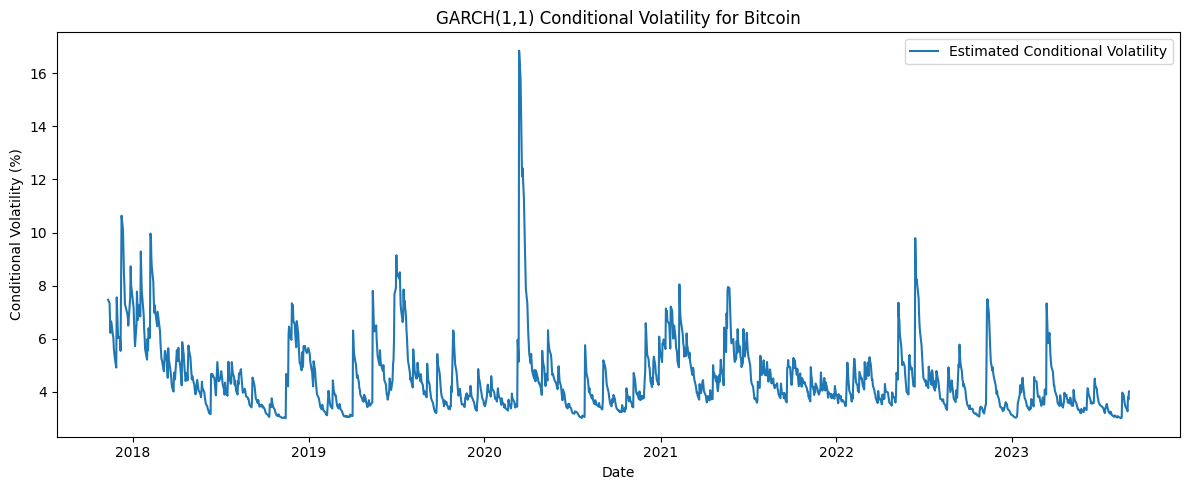

In [41]:
cond_vol = garch_res.conditional_volatility

plt.figure(figsize=(12, 5))
plt.plot(cond_vol.index, cond_vol, label="Estimated Conditional Volatility")

plt.title(f"GARCH(1,1) Conditional Volatility for {asset}")
plt.xlabel("Date")
plt.ylabel("Conditional Volatility (%)")
plt.legend()
plt.tight_layout()
plt.show()

In [48]:
from arch import arch_model
from statsmodels.tsa.arima.model import ARIMA
import numpy as np
import pandas as pd

# Store GARCH parameter results across folds
garch_param_results = []

# Expanding window loop
for end_train in range(initial_train_size, len(series) - forecast_horizon, step_size):
    
    # Select training data up to current fold
    train_cv = series.iloc[:end_train]

    try:
        # Step 1: Fit ARMA(1,1) model to capture mean dynamics
        arma_cv = ARIMA(train_cv, order=(1, 0, 1)).fit()

        # Step 2: Extract residuals from ARMA model
        resid_cv = pd.Series(arma_cv.resid, index=train_cv.index)

        # Step 3: Clean residuals (remove NaN and infinite values)
        resid_cv = resid_cv.replace([np.inf, -np.inf], np.nan).dropna()

        # Skip fold if too few observations (GARCH requires sufficient data)
        if len(resid_cv) < 50:
            continue

        # Step 4: Scale residuals to percentage (improves numerical stability)
        resid_cv = resid_cv * 100

        # Step 5: Fit GARCH(1,1) model on residuals
        garch_cv = arch_model(
            resid_cv,
            mean="Zero",     # Mean already modeled by ARMA
            vol="GARCH",     # GARCH volatility model
            p=1,
            q=1,
            dist="normal"    # Assume normal distribution
        ).fit(disp="off")

        # Step 6: Extract estimated parameters
        params = garch_cv.params

        alpha1 = params.get("alpha[1]", np.nan)
        beta1 = params.get("beta[1]", np.nan)

        # Step 7: Store results
        garch_param_results.append({
            "train_end_date": train_cv.index[-1],
            "omega": params.get("omega", np.nan),   # Long-run variance level
            "alpha1": alpha1,                      # Shock impact
            "beta1": beta1,                        # Persistence
            "alpha_plus_beta": alpha1 + beta1      # Volatility persistence measure
        })

    except Exception as e:
        # Skip fold if model fails to converge
        print(f"Skipped GARCH fold ending at {train_cv.index[-1]} due to error: {e}")

# Convert results to DataFrame
garch_param_df = pd.DataFrame(garch_param_results)

# Print summary
print("GARCH Parameter Stability Summary")

if len(garch_param_df) > 0:
    print(garch_param_df.head())
    print("\nAverage alpha + beta:", garch_param_df["alpha_plus_beta"].mean())
else:
    print("No valid GARCH results. Check data quality or sample size.")

GARCH Parameter Stability Summary
  train_end_date     omega    alpha1     beta1  alpha_plus_beta
0     2021-05-05  2.047453  0.137717  0.790538         0.928255
1     2021-06-16  2.017947  0.138566  0.793720         0.932286
2     2021-07-28  2.070730  0.139937  0.789984         0.929922
3     2021-09-08  2.028204  0.134908  0.794206         0.929114
4     2021-10-20  1.981967  0.124994  0.802858         0.927852

Average alpha + beta: 0.9322328530869729


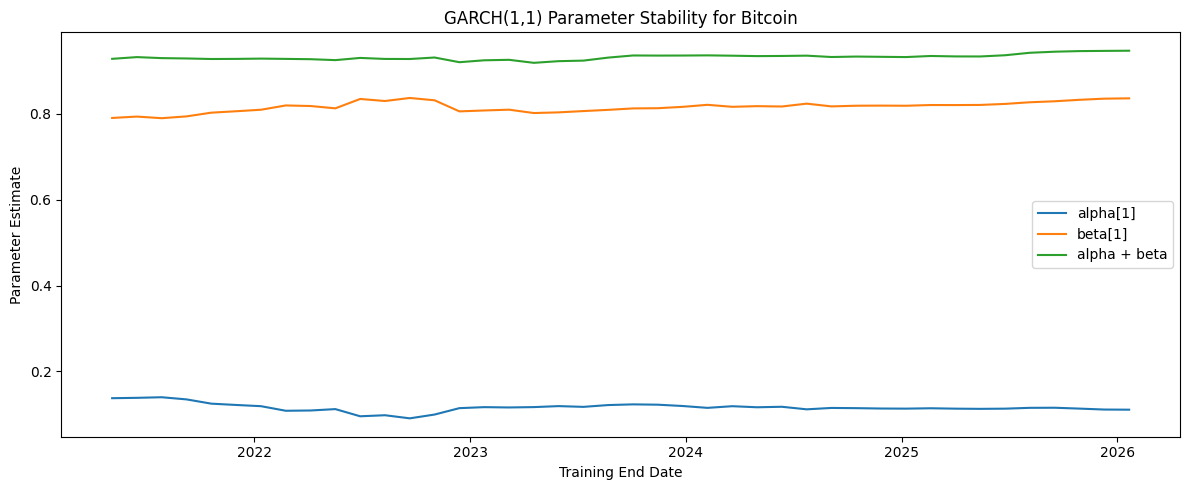

In [49]:
plt.figure(figsize=(12, 5))
plt.plot(garch_param_df["train_end_date"], garch_param_df["alpha1"], label="alpha[1]")
plt.plot(garch_param_df["train_end_date"], garch_param_df["beta1"], label="beta[1]")
plt.plot(garch_param_df["train_end_date"], garch_param_df["alpha_plus_beta"], label="alpha + beta")
plt.title(f"GARCH(1,1) Parameter Stability for {asset}")
plt.xlabel("Training End Date")
plt.ylabel("Parameter Estimate")
plt.legend()
plt.tight_layout()
plt.show()

Number of predictions: 33
MSE: 7.920223475190691
MAE: 2.149211783495483


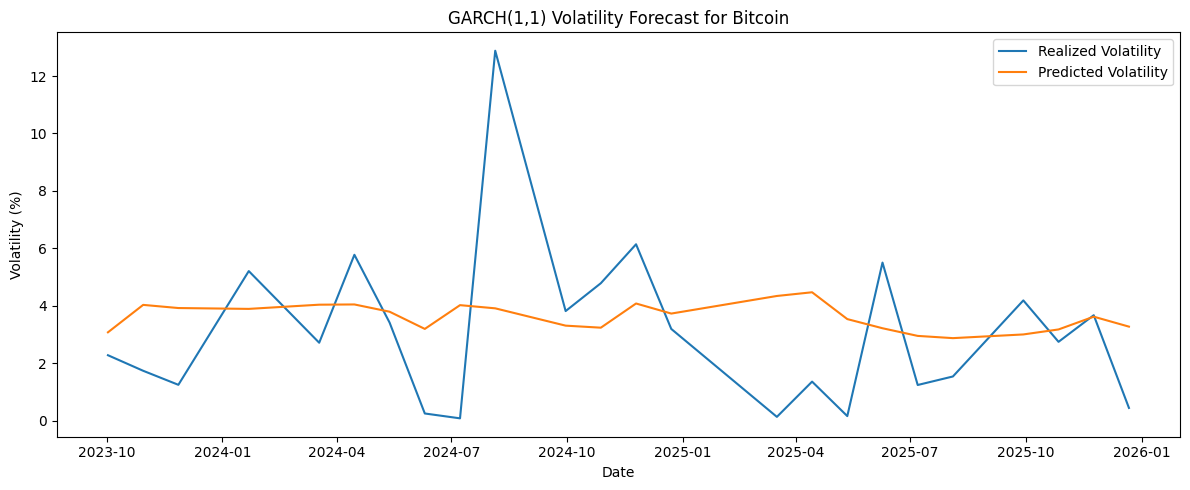

In [61]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from statsmodels.tsa.arima.model import ARIMA
from arch import arch_model
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Select asset
asset = "Bitcoin"
series = returns[asset].dropna().astype(float)

# Ensure datetime index
series.index = pd.to_datetime(series.index)
series = series.asfreq('B')

# Train-test split
split = int(len(series) * 0.7)
train = series.iloc[:split]
test = series.iloc[split:]

# Rolling GARCH forecast
step_size = 20
pred_list = []
date_list = []

for i in range(0, len(test), step_size):

    train_roll = series.iloc[:len(train) + i]

    arma_roll = ARIMA(train_roll, order=(1, 0, 1)).fit()
    resid_roll = pd.Series(arma_roll.resid, index=train_roll.index) * 100

    resid_roll = resid_roll.replace([np.inf, -np.inf], np.nan).dropna()

    if len(resid_roll) < 50:
        continue

    try:
        garch_roll = arch_model(
            resid_roll,
            mean="Zero",
            vol="GARCH",
            p=1,
            q=1
        ).fit(disp="off")

        forecast = garch_roll.forecast(horizon=1)
        var_pred = forecast.variance.iloc[-1, 0]

        pred_list.append(var_pred)
        date_list.append(test.index[i])

    except Exception as e:
        print(f"Skip step {i}: {e}")

pred_var = pd.Series(pred_list, index=date_list)

print("Number of predictions:", len(pred_var))

# Convert to volatility
pred_vol = np.sqrt(pred_var)

# Realized volatility
realized_vol = (test * 100).abs()

# Align data
df_vol = pd.concat([realized_vol, pred_vol], axis=1)
df_vol.columns = ["realized_vol", "predicted_vol"]
df_vol = df_vol.dropna()

# Evaluation
mse = mean_squared_error(df_vol["realized_vol"], df_vol["predicted_vol"])
mae = mean_absolute_error(df_vol["realized_vol"], df_vol["predicted_vol"])

print("MSE:", mse)
print("MAE:", mae)

# Plot
plt.figure(figsize=(12, 5))
plt.plot(df_vol.index, df_vol["realized_vol"], label="Realized Volatility")
plt.plot(df_vol.index, df_vol["predicted_vol"], label="Predicted Volatility")
plt.title(f"GARCH(1,1) Volatility Forecast for {asset}")
plt.xlabel("Date")
plt.ylabel("Volatility (%)")
plt.legend()
plt.tight_layout()
plt.show()

Volatility Forecast Evaluation
MSE: 1.8134
MAE: 1.0761


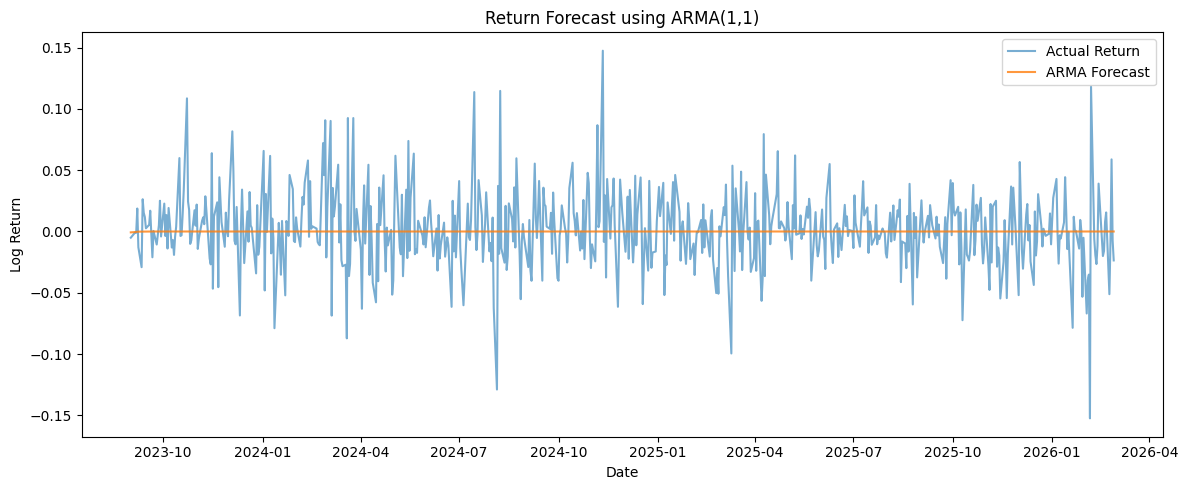

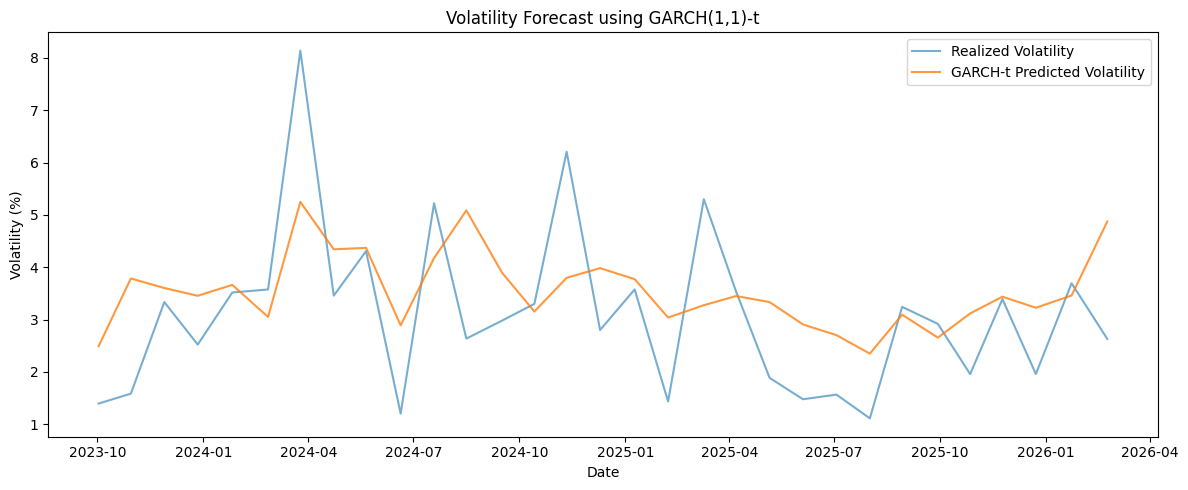

In [66]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from statsmodels.tsa.arima.model import ARIMA
from arch import arch_model
from sklearn.metrics import mean_squared_error, mean_absolute_error
import warnings

# Suppress convergence warnings (optional for cleaner output)
warnings.filterwarnings("ignore")


# Data preparation
series = returns["Bitcoin"].dropna().astype(float)
series.index = pd.to_datetime(series.index)
series = series.sort_index()

# Avoid forcing business-day frequency to prevent distortion of time series
# series = series.asfreq("B")
# series = series.ffill()


# Train-test split (70% training, 30% testing)
split = int(len(series) * 0.7)
train = series.iloc[:split]
test = series.iloc[split:]


# ARMA(1,1) model for conditional mean
arma = ARIMA(
    train,
    order=(1, 0, 1),
    trend="n"   # Remove constant term for stability
).fit(method_kwargs={"maxiter": 200})

# Forecast mean (returns)
arma_forecast = arma.forecast(steps=len(test))
arma_forecast = pd.Series(arma_forecast.values, index=test.index)


# Rolling GARCH-t model for conditional volatility
step_size = 20
pred_var = []
pred_index = []

for i in range(0, len(test), step_size):

    train_roll = series.iloc[:len(train) + i]

    try:
        # Fit ARMA model to obtain residuals
        arma_roll = ARIMA(
            train_roll,
            order=(1, 0, 1),
            trend="n"
        ).fit(method_kwargs={"maxiter": 100})

        resid_roll = arma_roll.resid * 100
        resid_roll = resid_roll.replace([np.inf, -np.inf], np.nan).dropna()

        # Ensure sufficient data for GARCH estimation
        if len(resid_roll) < 100:
            continue

        # Fit GARCH(1,1) model with Student-t distribution
        garch_roll = arch_model(
            resid_roll,
            mean="Zero",
            vol="GARCH",
            p=1,
            q=1,
            dist="t"
        ).fit(disp="off", show_warning=False)

        # One-step-ahead variance forecast
        forecast = garch_roll.forecast(horizon=1)
        var_pred = forecast.variance.iloc[-1, 0]

        # Filter unrealistic values to avoid instability
        if var_pred <= 0 or var_pred > 1000:
            continue

        pred_var.append(var_pred)
        pred_index.append(test.index[i])

    except:
        continue


# Convert predictions to pandas Series
pred_var = pd.Series(pred_var, index=pred_index)
pred_vol = np.sqrt(pred_var)


# Realized volatility (5-day rolling standard deviation)
realized_vol = test.rolling(5).std() * 100
realized_vol = realized_vol.loc[pred_index]


# Evaluation using volatility (same scale)
df_eval = pd.concat([realized_vol, pred_vol], axis=1)
df_eval.columns = ["realized_vol", "predicted_vol"]
df_eval = df_eval.dropna()

mse = mean_squared_error(df_eval["realized_vol"], df_eval["predicted_vol"])
mae = mean_absolute_error(df_eval["realized_vol"], df_eval["predicted_vol"])

print("Volatility Forecast Evaluation")
print(f"MSE: {mse:.4f}")
print(f"MAE: {mae:.4f}")


# Plot return forecast
plt.figure(figsize=(12, 5))
plt.plot(test.index, test, label="Actual Return", alpha=0.6)
plt.plot(test.index, arma_forecast, label="ARMA Forecast", alpha=0.8)

plt.title("Return Forecast using ARMA(1,1)")
plt.xlabel("Date")
plt.ylabel("Log Return")
plt.legend()
plt.tight_layout()
plt.show()


# Plot volatility forecast
plt.figure(figsize=(12, 5))
plt.plot(df_eval.index, df_eval["realized_vol"], label="Realized Volatility", alpha=0.6)
plt.plot(df_eval.index, df_eval["predicted_vol"], label="GARCH-t Predicted Volatility", alpha=0.8)

plt.title("Volatility Forecast using GARCH(1,1)-t")
plt.xlabel("Date")
plt.ylabel("Volatility (%)")
plt.legend()
plt.tight_layout()
plt.show()

ROLLING GARCH
MSE: 1.9162
MAE: 1.1372


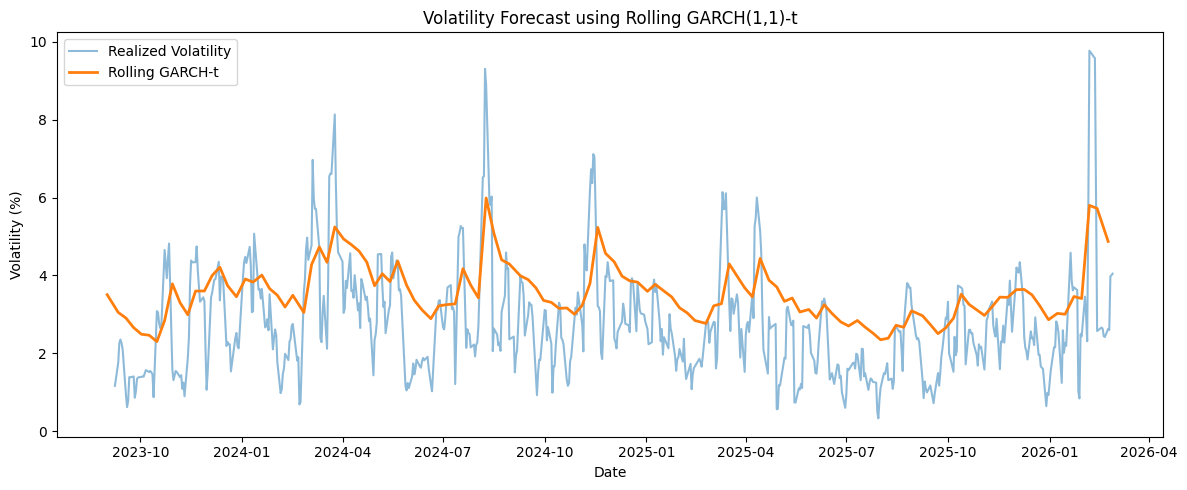

In [69]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from statsmodels.tsa.arima.model import ARIMA
from arch import arch_model
from sklearn.metrics import mean_squared_error, mean_absolute_error
import warnings

warnings.filterwarnings("ignore")


# 1. Prepare data
series = returns["Bitcoin"].dropna().astype(float)
series.index = pd.to_datetime(series.index)
series = series.sort_index()

# Train-test split
split = int(len(series) * 0.7)
train = series.iloc[:split]
test = series.iloc[split:]


# 2. Rolling GARCH (step = 5)
step_size = 5
rolling_var = []
rolling_index = []

for i in range(0, len(test), step_size):

    train_roll = series.iloc[:len(train) + i]

    try:
        # Fit ARMA(1,1) for mean
        arma_roll = ARIMA(train_roll, order=(1, 0, 1), trend="n").fit()

        # Get residuals (scaled)
        resid_roll = arma_roll.resid * 100
        resid_roll = resid_roll.dropna()

        if len(resid_roll) < 100:
            continue

        # Fit GARCH(1,1)-t
        garch_roll = arch_model(
            resid_roll,
            mean="Zero",
            vol="GARCH",
            p=1,
            q=1,
            dist="t"
        ).fit(disp="off")

        # One-step-ahead forecast
        forecast = garch_roll.forecast(horizon=1)
        var_pred = forecast.variance.iloc[-1, 0]

        # Filter extreme values
        if var_pred <= 0 or var_pred > 1000:
            continue

        rolling_var.append(var_pred)
        rolling_index.append(test.index[i])

    except:
        continue


# Convert to volatility (%)
rolling_var = pd.Series(rolling_var, index=rolling_index)
rolling_vol = np.sqrt(rolling_var)


# 3. Realized volatility (5-day rolling)
realized_vol = test.rolling(5).std() * 100
realized_roll = realized_vol.loc[rolling_vol.index]


# 4. Evaluation
df_roll = pd.concat([realized_roll, rolling_vol], axis=1).dropna()
df_roll.columns = ["realized", "predicted"]

mse = mean_squared_error(df_roll["realized"], df_roll["predicted"])
mae = mean_absolute_error(df_roll["realized"], df_roll["predicted"])

print("ROLLING GARCH")
print(f"MSE: {mse:.4f}")
print(f"MAE: {mae:.4f}")


# 5. Plot result
plt.figure(figsize=(12, 5))

plt.plot(realized_vol.index, realized_vol, label="Realized Volatility", alpha=0.5)
plt.plot(rolling_vol.index, rolling_vol, label="Rolling GARCH-t", linewidth=2)

plt.title("Volatility Forecast using Rolling GARCH(1,1)-t")
plt.xlabel("Date")
plt.ylabel("Volatility (%)")
plt.legend()
plt.tight_layout()
plt.show()

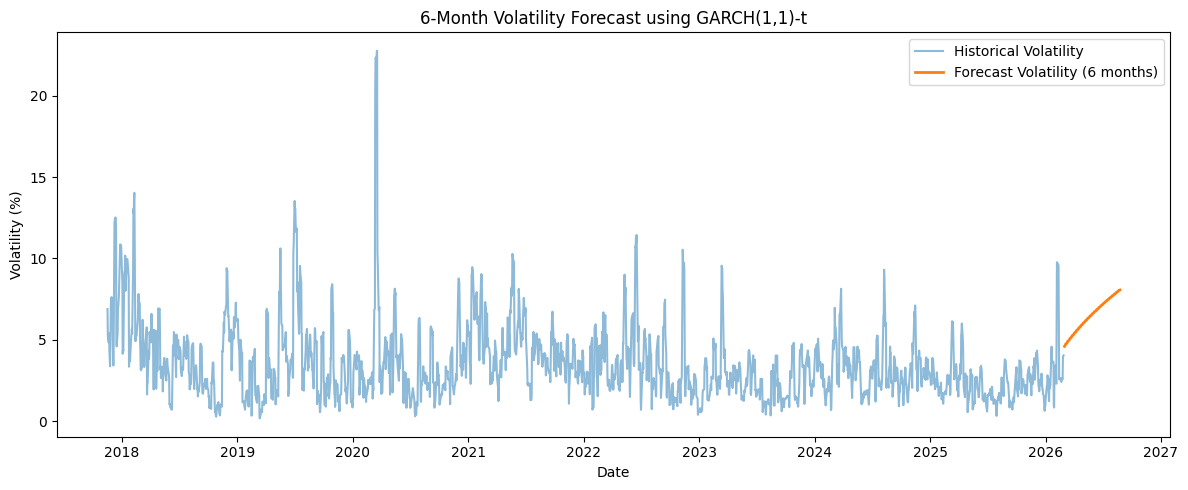

In [70]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from statsmodels.tsa.arima.model import ARIMA
from arch import arch_model


# 1. Prepare full data (use ALL data)
series = returns["Bitcoin"].dropna().astype(float)
series.index = pd.to_datetime(series.index)
series = series.sort_index()


# 2. Fit ARMA(1,1) on full sample
arma = ARIMA(series, order=(1, 0, 1), trend="n").fit()

# Get residuals
resid = arma.resid * 100
resid = resid.dropna()


# 3. Fit GARCH(1,1)-t on residuals
garch = arch_model(
    resid,
    mean="Zero",
    vol="GARCH",
    p=1,
    q=1,
    dist="t"
).fit(disp="off")


# 4. Forecast next 6 months
horizon = 126   # ~6 months (trading days)

forecast = garch.forecast(horizon=horizon)

# Extract variance forecast
future_var = forecast.variance.values[-1]

# Convert to volatility (%)
future_vol = np.sqrt(future_var)


# 5. Create future dates
last_date = series.index[-1]
future_dates = pd.bdate_range(start=last_date, periods=horizon + 1)[1:]

future_vol_series = pd.Series(future_vol, index=future_dates)


# 6. Plot historical + future
plt.figure(figsize=(12, 5))

# Historical volatility
hist_vol = series.rolling(5).std() * 100
plt.plot(hist_vol.index, hist_vol, label="Historical Volatility", alpha=0.5)

# Forecast
plt.plot(future_vol_series.index, future_vol_series,
         label="Forecast Volatility (6 months)",
         linewidth=2)

plt.title("6-Month Volatility Forecast using GARCH(1,1)-t")
plt.xlabel("Date")
plt.ylabel("Volatility (%)")
plt.legend()
plt.tight_layout()
plt.show()